In [1]:
import os
import sys
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from pathlib import Path
import pickle

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import to_hex
from matplotlib.lines import Line2D
import seaborn as sns

# 1. Data Preparation

In [2]:
%load_ext autoreload
%autoreload
import chip_utilities as utils

sys.path.insert(0, '..')
import sigmoid_fitting as sp
from experiment_data_loader import ExperimentDataLoader

exp_folder = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data"
# exp_paths = [Path(exp_folder, name) for name in os.listdir(exp_folder) if name != ".DS_Store"]
exp_path = Path(exp_folder, "D20250808_E00_C00_F4500KHz_U_Sample_7")

data_path = os.path.join(exp_path, "curve_for_training_2.pkl")

with open(data_path, 'rb') as f:
    training_data = pickle.load(f)

timestamps = training_data["timestamps"]
Y_well = training_data["Y_well"]
dataset_name = training_data["dataset_name"]
dataset = training_data["dataset"]
kinetic_features = training_data["kinetic_features"]

curve_path = Path(exp_path, "preprocessed_curves_data.pkl")
with open(curve_path, 'rb') as f:
    processed_curve_results = pickle.load(f)
    
metadata_df = pd.DataFrame(processed_curve_results["metadata"])

for i in range(len(kinetic_features)):
    kinetic_features[i] = pd.concat([kinetic_features[i],metadata_df], axis=1)

In [3]:
# for name, kf in zip(dataset_name, kinetic_features):
#     print("="*75)
#     print(name)
#     print(np.sum(kf.isna(),axis=0))
#     print("="*75)

kinetic_features[0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'dy_xms', 'dy_xp1', 'dy_xp2',
       'd2y_xp1', 'd2y_xp2', 'threshold_distance', 'first_half_distance',
       'second_half_distance', 'distance_asymmetry_index',
       'peak_shifting_distance', 'A1', 'A2', 'area_asymmetry_index',
       'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0', 'F0', 'msc_mahal_dist',
       'msc_label_0.001', 'amf_label_Send', 'amf_label_Send_abs',
       'amf_label_Send_fit', 'amf_label_Send_fit_abs',
       'mean_std_outlier_label_3sigma', 'pixel_row_idx', 'pixel_col_idx',
       'temp_group_idx', 'num_active_pixels_in_temp_group',
       'well_temp_lin2d_mean', 'well_2d_temp_npr_mean'],
      dtype='object')

# 2. Additional Features Extraction

In [4]:
def get_send(timestamps, curves_2d, send_n=[5, 10, 15, 20, 25]):
    dy_dx_list = Parallel(n_jobs=-1, backend="loky", batch_size='auto')(
        delayed(sp.calculate_first_derivative)(timestamps, y) for y in curves_2d
    )
    dy_dx = np.array(dy_dx_list) 
    
    send_dict = {}
    for n in send_n:
        send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
        send_dict[f"send_abs_{n}"] = np.nanmean(np.abs(dy_dx[:, -n:]), axis=1)
        
    return send_dict

for idx, (name, features_df, curves_2d) in enumerate(zip(dataset_name, kinetic_features, dataset)):
    add_features = get_send(timestamps, curves_2d)
    add_features["FFI"] = curves_2d[:, -1]    
    add_features["F_range"] = curves_2d[:, -1] - curves_2d[:, 0]

    df_new_features = pd.DataFrame(add_features).reset_index(drop=True)
    
    features_df = features_df.reset_index(drop=True)
    kinetic_features[idx] = pd.concat([features_df, df_new_features], axis=1)

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/2446840296.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/2446840296.py:10: RuntimeWarning: Mean of empty slice
  send_dict[f"send_abs_{n}"] = np.nanmean(np.abs(dy_dx[:, -n:]), axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/2446840296.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/2446840296.py:10: RuntimeWarning: Mean of empty slice
  send_dict[f"send_abs_{n}"] = np.nanmean(np.abs(dy_dx[:, -n:]), axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/2446840296.py:9: RuntimeWarning: Mean of empty slice
  send_dict[f"send_{n}"] = np.nanmean(dy_dx[:, -n:], axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/2446840296.py:

# 3. Feature Linear Correlation Check

In [5]:
a = features_df.select_dtypes(include=['number', 'float', 'int']).columns
b = features_df.columns
list(set(a).symmetric_difference(set(b)))

['5p_sigmoid_fitted', '5p_sigmoid_fitted_dydx']

In [6]:
a.shape

(53,)

In [7]:
kinetic_features[0].msc_mahal_dist

0        1.182228
1        2.748745
2        1.696523
3        1.457594
4        1.916295
           ...   
12042    0.302345
12043    0.206501
12044    1.606371
12045    0.223726
12046    0.298208
Name: msc_mahal_dist, Length: 12047, dtype: float64

In [8]:
# ====================================================================
# FEATURE GROUPS & EXCLUSIONS SETUP
# ====================================================================
# Converted to a list of lists since labels (A, B, etc.) aren't strictly needed

feature_groups = [
    # 1. Base Transformations
    ['F0', 'log_F0'],

    # 2. Alias Measurements (End-of-Curve Slopes)
    ['send_5', 'send_10', 'send_15', 'send_20', 'send_25', 'send_abs_5', 'send_abs_10', 'send_abs_15', 'send_abs_20', 'send_abs_25', 'Send', 'Send_abs', 'Send_fit', 'Send_fit_abs'],

    # 3. Alias Measurements (Max Amplitude / Baseline)
    ['F_max', 'Fm', 'FFI', 'F_range'],

    # 4. Alias Measurements (Reaction Threshold Times)
    ['ct_idx', 'Ct'],

    # 5. Parent-Child: Tangent at Inflection 
    # (Cy0 is literally a math equation of Cs, As, and Sc)
    ['Cy0', 'Cs', 'As', 'Sc'],

    # 6. Geometrical Siblings: First Half
    # (Distance and Area both span precisely from xs to xms)
    ['first_half_distance', 'A1', 'xs', 'xms'],

    # 7. Geometrical Siblings: Second Half
    # (Distance and Area both span precisely from xms to xe)
    ['second_half_distance', 'A2', 'xms', 'xe'],

    # 8. Parent-Child: Total Threshold Distance
    ['threshold_distance', 'xs', 'xe'],

    # 9. Parent-Child: Peak Shifting
    ['peak_shifting_distance', 'xp1', 'xp2'],

    # 10. Parent-Child: Asymmetry Indices 
    # (Ratios of directly opposing features)
    ['distance_asymmetry_index', 'first_half_distance', 'second_half_distance'],
    ['area_asymmetry_index', 'A1', 'A2'],
    ['peak_asymmetry_index', 'd2y_xp1', 'd2y_xp2'],

    # 11. Coordinate Locking: Max Slope Point (xms)
    ['xms', 'y_xms', 'dy_xms'],

    # 12. Coordinate Locking: Max Acceleration Point (xp1)
    ['xp1', 'y_xp1', 'dy_xp1', 'd2y_xp1'],

    # 13. Coordinate Locking: Max Deceleration Point (xp2)
    ['xp2', 'y_xp2', 'dy_xp2', 'd2y_xp2'],

    # 14. Coordinate Locking: Start and End Thresholds
    ['xs', 'y_xs'],
    ['xe', 'y_xe'],

    # 15. Additional, all F/y values
    ['y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'F_max', 'Fm', 'FFI', 'F_range']
]

# feature_groups = [
#     ['y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2'],
#     ['dy_xms', 'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2'],
#     ["threshold_distance", "second_half_distance", "xe", "distance_asymmetry_index"],
#     ["threshold_distance", "first_half_distance", "xs", "distance_asymmetry_index"],
#     ["first_half_distance", "xms"],
#     ["second_half_distance", "xms"],
#     ["peak_shifting_distance", "xp1"],
#     ["peak_shifting_distance", "xp2"],
#     ["area_asymmetry_index", "A1"],
#     ["area_asymmetry_index", "A2"],
#     ["xs", "A1"],
#     ["xms", "A1"],
#     ["xe", "A2"],
#     ["xms", "A2"],
# ]

excluded_features = [
    'TH', 'msc_mahal_dist', 'msc_label_0.001', 'amf_label_Send', 
    'amf_label_Send_abs', 'amf_label_Send_fit', 'amf_label_Send_fit_abs', 
    'mean_std_outlier_label_3sigma'
]

In [9]:
import os
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import itertools  # <-- Required for testing feature combinations

linear_feature_combinations = []

# ====================================================================
# HTML & HEATMAP GENERATION
# ====================================================================
html_content = """
<html>
<head><title>Correlation Heatmaps</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center;">
    <h1 style="padding: 20px;">Experiment Correlation Heatmaps</h1>
"""

for name, features_df in zip(dataset_name, kinetic_features):
    clean_title = name.replace("_", " ").title()
    print(f"Generating heatmap and feature combinations for: {clean_title}...")
    
    # Select numeric features and calculate correlation
    numeric_df = features_df.select_dtypes(include=['number', 'float', 'int'])
    corr = numeric_df.corr()
    
    # ----------------------------------------------------------------
    # EXTRACT THE SINGLE BEST FEATURE COMBINATION (NEW LOGIC)
    # ----------------------------------------------------------------
    corr_matrix = corr.abs() 
    dataset_combinations = []
    
    # Get valid features (exclude globally excluded ones)
    valid_features = [f for f in corr_matrix.columns if f not in excluded_features]
    
    # Build a "cannot pair" dictionary based on the multi-group rule
    cannot_pair_with = {f: set() for f in valid_features}
    for f in valid_features:
        for group in feature_groups:
            if f in group:
                cannot_pair_with[f].update(group)
                
    best_triplet = []
    max_score = -1
    
    # Search all valid triplets to find the one with the highest total inter-correlation
    for f1, f2, f3 in itertools.combinations(valid_features, 3):
        
        # RULE 1 CHECK: Ensure none of the 3 features share a group
        if f2 in cannot_pair_with[f1] or f3 in cannot_pair_with[f1] or f3 in cannot_pair_with[f2]:
            continue 
            
        # RULE 2 CHECK: Calculate their inter-correlation score
        c12 = corr_matrix.loc[f1, f2]
        c13 = corr_matrix.loc[f1, f3]
        c23 = corr_matrix.loc[f2, f3]
        
        score = c12 + c13 + c23
        
        # If this triangle is stronger than our current best, save it
        if score > max_score:
            max_score = score
            best_triplet = [f1, f2, f3]
            
    # Save the best triplet to this dataset's list
    if best_triplet:
        avg_corr = max_score / 3 
        print(f"  -> Best Triplet: {best_triplet} (Avg Inter-correlation: {avg_corr:.3f})")
        dataset_combinations = best_triplet.copy()
    else:
        print("  -> Could not find a valid triplet that satisfies all constraints.")
        
    # Append this dataset's unique combination to the master list
    linear_feature_combinations.append(dataset_combinations)
    # ----------------------------------------------------------------

    # Apply the mask for the heatmap visualization (values < 0.5 become 0)
    corr_viz = corr.mask(corr.abs() < 0.5, 0)
    
    # MASSIVE figure size so columns don't overlap
    fig, ax = plt.subplots(figsize=(24, 20))
    
    # Plot heatmap
    sns.heatmap(corr_viz, cmap="coolwarm", center=0, 
                xticklabels=True, yticklabels=True, 
                linewidths=0.5, linecolor='lightgrey', 
                cbar_kws={"shrink": .75}, ax=ax)
    
    # Shrink label sizes and rotate them to fit columns perfectly
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    
    plt.title(f"Correlation Matrix: {clean_title}", fontsize=22, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Save plot to a temporary memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig) 
    buf.seek(0)
    
    # Encode to Base64 and embed as an image tag in the HTML
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    html_content += f'''
    <div style="margin: 40px auto; width: 95%; background: white; padding: 20px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1);">
        <img src="data:image/png;base64,{img_base64}" style="max-width: 100%; height: auto;">
    </div>
    '''

# Close the HTML and write the single file to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "all_correlation_heatmaps.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved all heatmaps to {save_path}")
print(f"  -> Extracted the best feature triplets for all {len(linear_feature_combinations)} datasets.")

Generating heatmap and feature combinations for: Ori Curves...
  -> Best Triplet: ['y_xms', 'second_half_distance', 'A1'] (Avg Inter-correlation: 0.714)
Generating heatmap and feature combinations for: Ori Curves Avg...
  -> Best Triplet: ['y_xs', 'threshold_distance', 'log_F0'] (Avg Inter-correlation: 0.697)
Generating heatmap and feature combinations for: Original Fitted Full...
  -> Best Triplet: ['dy_xms', 'dy_xp1', 'dy_xp2'] (Avg Inter-correlation: 0.909)
Generating heatmap and feature combinations for: Original Fitted Stretched...
  -> Best Triplet: ['dy_xms', 'dy_xp1', 'dy_xp2'] (Avg Inter-correlation: 0.909)
Generating heatmap and feature combinations for: Cleaned Std Fitted Full...
  -> Best Triplet: ['Fb', 'y_xs', 'F0'] (Avg Inter-correlation: 0.949)
Generating heatmap and feature combinations for: Cleaned Std Fitted Stretched...
  -> Best Triplet: ['Fb', 'y_xs', 'F0'] (Avg Inter-correlation: 0.938)
Generating heatmap and feature combinations for: Cleaned Lowest Fitted Full..

In [10]:
linear_feature_combinations

[['y_xms', 'second_half_distance', 'A1'],
 ['y_xs', 'threshold_distance', 'log_F0'],
 ['dy_xms', 'dy_xp1', 'dy_xp2'],
 ['dy_xms', 'dy_xp1', 'dy_xp2'],
 ['Fb', 'y_xs', 'F0'],
 ['Fb', 'y_xs', 'F0'],
 ['Fb', 'y_xs', 'F0'],
 ['Fb', 'y_xs', 'F0'],
 ['dy_xms', 'dy_xp1', 'dy_xp2'],
 ['dy_xms', 'dy_xp1', 'dy_xp2'],
 ['Fb', 'y_xs', 'F0'],
 ['dy_xms', 'dy_xp1', 'dy_xp2'],
 ['Fb', 'y_xs', 'F0'],
 ['dy_xms', 'dy_xp1', 'dy_xp2']]

In [11]:
import os
import gc
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ensure we have categorical colors for the dots
try:
    colors = pd.factorize(Y_well)[0]
    cmap = 'tab10'
except NameError:
    colors = '#3498db'
    cmap = None

# 2. Initialize the Master HTML string
html_content = """
<html>
<head><title>Best 3D Feature Combinations</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center; margin: 0; padding: 20px;">
    <h1 style="color: #333; margin-bottom: 10px;">Best 3D Feature Combinations per Dataset</h1>
    <p style="color: #666; margin-bottom: 40px;">Displaying the highest inter-correlated valid feature triplet for each experiment.</p>
"""

# RULE 1: Start a SINGLE Flexbox container so datasets can sit side-by-side
html_content += "<div style='display: flex; flex-wrap: wrap; justify-content: center; gap: 20px;'>"

for name, kf, dataset_combs in zip(dataset_name, kinetic_features, linear_feature_combinations):
    
    # Failsafe: Skip if the previous step couldn't find a valid triplet for this dataset
    if not dataset_combs:
        continue
        
    clean_title = name.replace("_", " ").title()
    print(f"Generating 3D plot for dataset: {clean_title}...")
    
    # Extract the single best triplet
    comb = dataset_combs.copy()
    x_feat, y_feat, z_feat = comb[:3]
    
    # RULE 2: Recalculate correlation dynamically to display in the subtitle
    corr_matrix = kf[[x_feat, y_feat, z_feat]].corr(method='pearson').abs()
    score = corr_matrix.loc[x_feat, y_feat] + corr_matrix.loc[x_feat, z_feat] + corr_matrix.loc[y_feat, z_feat]
    avg_corr = score / 3
    
    # Sanitize data to prevent t-SNE / Matplotlib crashes
    df_3d = kf[[x_feat, y_feat, z_feat]].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_vals = df_3d.values
    
    # Create the 3D figure
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    if cmap:
        ax.scatter(X_vals[:, 0], X_vals[:, 1], X_vals[:, 2], c=colors, cmap=cmap, s=30, alpha=0.8, edgecolor='k')
    else:
        ax.scatter(X_vals[:, 0], X_vals[:, 1], X_vals[:, 2], color=colors, s=30, alpha=0.8, edgecolor='k')
    
    # RULE 2: Apply Dataset Name as Title, and Features + Score as Subtitle
    subtitle = f"[{x_feat}, {y_feat}, {z_feat}]\nAvg Inter-Correlation: {avg_corr:.3f}"
    ax.set_title(f"{clean_title}\n{subtitle}", fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xlabel(x_feat, fontsize=10, fontweight='bold', labelpad=10)
    ax.set_ylabel(y_feat, fontsize=10, fontweight='bold', labelpad=10)
    ax.set_zlabel(z_feat, fontsize=10, fontweight='bold', labelpad=15)
    
    plt.tight_layout()
    
    # Save plot to memory
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', pad_inches=0.5, facecolor='white')
    plt.close(fig)
    buf.seek(0)
    
    # Encode and embed
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    # The 'width: 45%' forces the 2-column layout
    html_content += f'''
    <div style="background: white; padding: 15px; box-shadow: 0px 4px 8px rgba(0,0,0,0.05); border-radius: 8px; width: 45%; min-width: 450px;">
        <img src="data:image/png;base64,{img_base64}" style="width: 100%; height: auto;">
    </div>
    '''
    
    gc.collect()

# Close the single flexbox container
html_content += "</div>"

# 3. Close the HTML and write to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "best_feature_combinations_3D.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved 3D combination plots to {save_path}")

Generating 3D plot for dataset: Ori Curves...
Generating 3D plot for dataset: Ori Curves Avg...
Generating 3D plot for dataset: Original Fitted Full...
Generating 3D plot for dataset: Original Fitted Stretched...
Generating 3D plot for dataset: Cleaned Std Fitted Full...
Generating 3D plot for dataset: Cleaned Std Fitted Stretched...
Generating 3D plot for dataset: Cleaned Lowest Fitted Full...
Generating 3D plot for dataset: Cleaned Lowest Fitted Stretched...
Generating 3D plot for dataset: Avg Fitted Full...
Generating 3D plot for dataset: Avg Fitted Stretched...
Generating 3D plot for dataset: Avg Cleaned Std Fitted Full...
Generating 3D plot for dataset: Avg Cleaned Std Fitted Stretched...
Generating 3D plot for dataset: Avg Cleaned Lowest Fitted Full...
Generating 3D plot for dataset: Avg Cleaned Lowest Fitted Stretched...

  -> Successfully saved 3D combination plots to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/best_fea

# 4. Feature Importance (Non Linear Correlation) Check

In [ ]:
import os
import numpy as np
import base64
from io import BytesIO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

importance_dfs = []
# 1. Initialize the Master HTML string
html_content = """
<html>
<head><title>Random Forest Feature Importances</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center;">
    <h1 style="padding: 20px; color: #333;">Feature Importance Analysis</h1>
"""

for name, features_df in zip(dataset_name, kinetic_features):
    clean_title = name.replace("_", " ").title()
    print(f"Generating feature importance plot for: {clean_title}...")
    
    # 2. Isolate numeric columns 
    numeric_df = features_df.select_dtypes(include=['number', 'float', 'int'])
    
    # --- THE FIX: Clean Infinity and NaN values ---
    # Replace inf/-inf with NaN, then fill all NaNs with 0
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    feature_cols = numeric_df.columns
    
    # 3. Scale and Train Random Forest
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(numeric_df)
    
    rf = ≈(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled, Y_well)
    
    # 4. Create DataFrame of importances and sort it descending
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf.feature_importances_
    }).sort_values(by='importance', ascending=False)
    
    # 5. Plotting (Tall figure to comfortably fit 60 features)
    fig, ax = plt.subplots(figsize=(12, 18))
    
    sns.barplot(
        data=importance_df, 
        x='importance', 
        y='feature', 
        palette='viridis', 
        ax=ax
    )
    
    ax.set_title(f"Random Forest Feature Importances: {clean_title}", fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Importance Score", fontsize=14, fontweight='bold')
    ax.set_ylabel("Features", fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10) 
    ax.grid(axis='x', linestyle='--', alpha=0.6) 
    
    plt.tight_layout()
    
    # 6. Save plot to a temporary memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig) 
    buf.seek(0)
    
    # 7. Encode to Base64 and embed
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    html_content += f'''
    <div style="margin: 40px auto; width: 90%; max-width: 1200px; background: white; padding: 20px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1); border-radius: 8px;">
        <img src="data:image/png;base64,{img_base64}" style="width: 100%; height: auto;">
    </div>
    '''
    importance_dfs.append(importance_df)
    
# 8. Close HTML and write to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "all_feature_importances.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved all feature importance plots to {save_path}")

Generating feature importance plot for: Ori Curves...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/1955818174.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generating feature importance plot for: Ori Curves Avg...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/1955818174.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generating feature importance plot for: Original Fitted Full...


...

Generating feature importance plot for: Avg Cleaned Lowest Fitted Full...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/1955818174.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generating feature importance plot for: Avg Cleaned Lowest Fitted Stretched...


/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_51593/1955818174.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



  -> Successfully saved all feature importance plots to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/all_feature_importances.html


In [13]:
feature_importance_list = []
for name, importance in zip(dataset_name, importance_dfs):
    # Set feature as index and rename the importance column to the dataset name
    df_renamed = importance.set_index("feature").rename(columns={'importance': name})
    feature_importance_list.append(df_renamed)

feature_importance_df = pd.concat(feature_importance_list, axis=1)
feature_importance_df = feature_importance_df.reset_index()

In [14]:
# ====================================================================
# 2. EXTRACT TOP 5 IMPORTANT COMBINATIONS (Greedy Selection)
# ====================================================================
important_feature_combinations = []

print("Extracting independent Top 5 features per dataset...")

for name, imp_df in zip(dataset_name, importance_dfs):
    clean_title = name.replace("_", " ").title()
    
    # Filter out globally excluded features
    valid_df = imp_df[~imp_df['feature'].isin(excluded_features)].copy()
    
    # Pre-calculate the multi-group conflict dictionary
    cannot_pair_with = {f: set() for f in valid_df['feature']}
    for f in valid_df['feature']:
        for group in feature_groups:
            if f in group:
                cannot_pair_with[f].update(group)
                
    selected_features = []
    total_importance = 0
    
    # Iterate through the DataFrame (which is already sorted by highest importance)
    for _, row in valid_df.iterrows():
        candidate = row['feature']
        imp_score = row['importance']
        
        # Check if this candidate conflicts with any feature we have ALREADY selected
        conflict = any(candidate in cannot_pair_with[sel] for sel in selected_features)
        
        if not conflict:
            selected_features.append(candidate)
            total_importance += imp_score
            
        # Stop once we have our Top 5 strictly independent features
        if len(selected_features) == 5:
            break
            
    important_feature_combinations.append(selected_features)
    print(f"  -> {clean_title}: {selected_features} (Summed Importance: {total_importance:.3f})")

Extracting independent Top 5 features per dataset...
  -> Ori Curves: ['ct_idx', 'Cy0', 'Fb', 'F_max', 'Send_fit_abs'] (Summed Importance: 0.271)
  -> Ori Curves Avg: ['Ct', 'Cy0', 'F_range', 'xs', 'Send_fit_abs'] (Summed Importance: 0.229)
  -> Original Fitted Full: ['Ct', 'xms', 'F_range', 'xp1', 'pixel_col_idx'] (Summed Importance: 0.199)
  -> Original Fitted Stretched: ['Ct', 'xms', 'F_range', 'xp1', 'pixel_col_idx'] (Summed Importance: 0.199)
  -> Cleaned Std Fitted Full: ['F_max', 'pixel_col_idx', 'ct_idx', 'log_F0', 'Cy0'] (Summed Importance: 0.150)
  -> Cleaned Std Fitted Stretched: ['F_range', 'pixel_col_idx', 'log_F0', 'Ct', 'd2y_xp2'] (Summed Importance: 0.162)
  -> Cleaned Lowest Fitted Full: ['well_2d_temp_npr_mean', 'well_temp_lin2d_mean', 'temp_group_idx', 'pixel_col_idx', 'num_active_pixels_in_temp_group'] (Summed Importance: 0.360)
  -> Cleaned Lowest Fitted Stretched: ['well_2d_temp_npr_mean', 'well_temp_lin2d_mean', 'temp_group_idx', 'pixel_col_idx', 'num_active_pixe

In [15]:
import os
import gc
import base64
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Prepare the color labels (Assuming Y_well is available in your environment)
try:
    y_full = pd.factorize(Y_well)[0]
    cmap = 'tab10'
except NameError:
    y_full = '#3498db'
    cmap = None

# 2. Initialize the Master HTML string
html_content = """
<html>
<head><title>Independent Features: 3D & t-SNE Analysis</title></head>
<body style="font-family: Arial, sans-serif; background-color: #f4f4f9; text-align: center;">
    <h1 style="padding: 20px; color: #333;">Top 5 Independent Features Dimensionality Reduction</h1>
    <p style="color: #666; margin-bottom: 40px;">Visualizing the highest importance features after removing mathematical redundancies.</p>
"""

# Iterate using the important_feature_combinations generated from the greedy selection
for name, top_5_features, kf in zip(dataset_name, important_feature_combinations, kinetic_features):
    clean_title = name.replace("_", " ").title()
    print(f"Generating 3D and t-SNE plots for: {clean_title}...")
    
    # Extract the top 3 from the 5 independent features for the 3D plot
    top_3_features = top_5_features[:3]
    
    # 3. Extract and Sanitize Data (Prevents TSNE crashing on Inf/NaN)
    df_top5 = kf[top_5_features].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_top5 = df_top5.values
    X_top3 = df_top5[top_3_features].values
    
    # 4. Perform t-SNE on the Top 5 features
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_top5)
    
    # 5. Create a 1x2 Figure
    fig = plt.figure(figsize=(22, 9))
    
    # --- COLUMN 1: 3D SCATTER PLOT ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    if cmap:
        ax1.scatter(X_top3[:, 0], X_top3[:, 1], X_top3[:, 2], c=y_full, cmap=cmap, s=40, alpha=0.8, edgecolor='k')
    else:
        ax1.scatter(X_top3[:, 0], X_top3[:, 1], X_top3[:, 2], color=y_full, s=40, alpha=0.8, edgecolor='k')
        
    subtitle_all_5 = ", ".join(top_5_features)
    ax1.set_title(f"{clean_title}\n(Top 3 Features: {', '.join(top_3_features)})", fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel(top_3_features[0], fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_ylabel(top_3_features[1], fontsize=11, fontweight='bold', labelpad=10)
    ax1.set_zlabel(top_3_features[2], fontsize=11, fontweight='bold', labelpad=15)
    
    # --- COLUMN 2: 2D t-SNE PLOT ---
    ax2 = fig.add_subplot(1, 2, 2)
    if cmap:
        ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_full, cmap=cmap, s=40, alpha=0.8, edgecolor='k')
    else:
        ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], color=y_full, s=40, alpha=0.8, edgecolor='k')
        
    ax2.set_title(f"{clean_title}\n(t-SNE on All 5 Features: {subtitle_all_5})", fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel("t-SNE Dimension 1", fontsize=12, fontweight='bold')
    ax2.set_ylabel("t-SNE Dimension 2", fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    
    # 6. Save plot to a temporary memory buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight', pad_inches=0.5, facecolor='white')
    plt.close(fig) # Destroy figure to free RAM
    buf.seek(0)
    
    # 7. Encode to Base64 and embed as an image tag in the HTML
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    html_content += f'''
    <div style="margin: 40px auto; width: 95%; max-width: 1600px; background: white; padding: 20px; box-shadow: 0px 4px 10px rgba(0,0,0,0.1); border-radius: 8px;">
        <img src="data:image/png;base64,{img_base64}" style="width: 100%; height: auto;">
    </div>
    '''
    
    # Aggressive memory cleanup
    gc.collect()

# 8. Close HTML and write to disk
html_content += "</body></html>"

save_path = os.path.join(exp_path, "independent_features_tsne_and_3d.html")
with open(save_path, "w") as f:
    f.write(html_content)

print(f"\n  -> Successfully saved all 3D & t-SNE plots to {save_path}")

Generating 3D and t-SNE plots for: Ori Curves...
Generating 3D and t-SNE plots for: Ori Curves Avg...
Generating 3D and t-SNE plots for: Original Fitted Full...
Generating 3D and t-SNE plots for: Original Fitted Stretched...
Generating 3D and t-SNE plots for: Cleaned Std Fitted Full...
Generating 3D and t-SNE plots for: Cleaned Std Fitted Stretched...
Generating 3D and t-SNE plots for: Cleaned Lowest Fitted Full...
Generating 3D and t-SNE plots for: Cleaned Lowest Fitted Stretched...
Generating 3D and t-SNE plots for: Avg Fitted Full...
Generating 3D and t-SNE plots for: Avg Fitted Stretched...
Generating 3D and t-SNE plots for: Avg Cleaned Std Fitted Full...
Generating 3D and t-SNE plots for: Avg Cleaned Std Fitted Stretched...
Generating 3D and t-SNE plots for: Avg Cleaned Lowest Fitted Full...
Generating 3D and t-SNE plots for: Avg Cleaned Lowest Fitted Stretched...

  -> Successfully saved all 3D & t-SNE plots to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D202

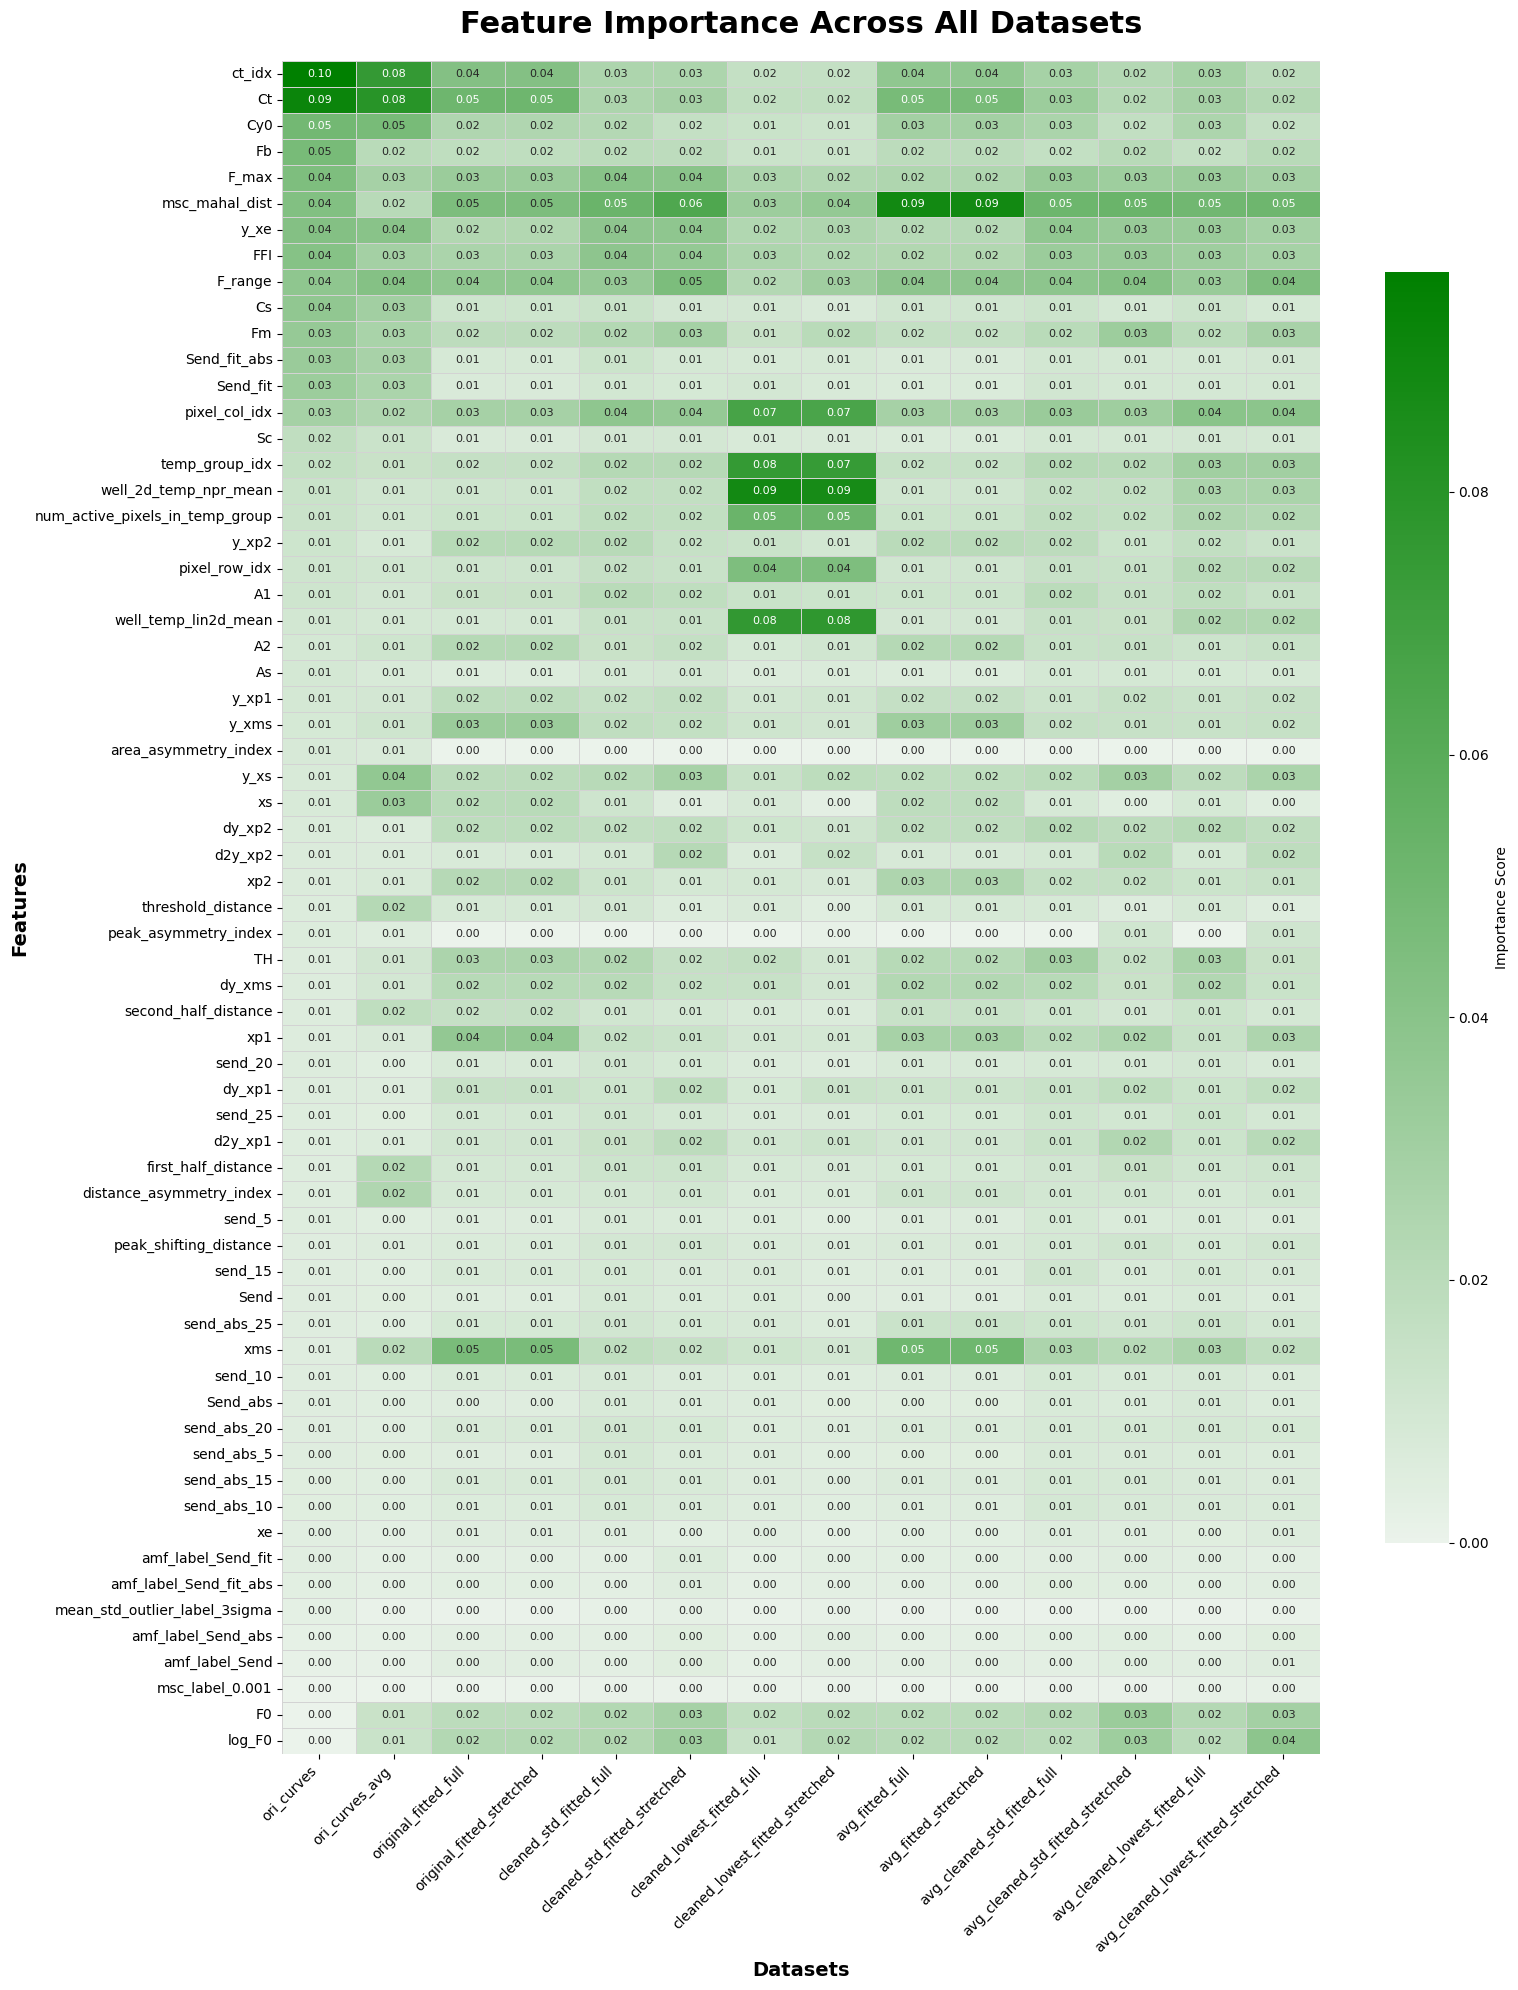

In [16]:
heatmap_data = feature_importance_df.set_index('feature')
fig, ax = plt.subplots(figsize=(16, 20))
custom_cmap = sns.light_palette("green", as_cmap=True)
sns.heatmap(
    heatmap_data, 
    cmap=custom_cmap, 
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5, 
    linecolor='lightgrey',
    cbar_kws={"shrink": .75, "label": "Importance Score"},
    ax=ax
)

ax.set_title("Feature Importance Across All Datasets", fontsize=22, fontweight='bold', pad=20)
ax.set_ylabel("Features", fontsize=14, fontweight='bold')
ax.set_xlabel("Datasets", fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
important_feature_combinations

[['ct_idx', 'Cy0', 'Fb', 'F_max', 'Send_fit_abs'],
 ['Ct', 'Cy0', 'F_range', 'xs', 'Send_fit_abs'],
 ['Ct', 'xms', 'F_range', 'xp1', 'pixel_col_idx'],
 ['Ct', 'xms', 'F_range', 'xp1', 'pixel_col_idx'],
 ['F_max', 'pixel_col_idx', 'ct_idx', 'log_F0', 'Cy0'],
 ['F_range', 'pixel_col_idx', 'log_F0', 'Ct', 'd2y_xp2'],
 ['well_2d_temp_npr_mean',
  'well_temp_lin2d_mean',
  'temp_group_idx',
  'pixel_col_idx',
  'num_active_pixels_in_temp_group'],
 ['well_2d_temp_npr_mean',
  'well_temp_lin2d_mean',
  'temp_group_idx',
  'pixel_col_idx',
  'num_active_pixels_in_temp_group'],
 ['xms', 'Ct', 'F_range', 'Cy0', 'pixel_col_idx'],
 ['xms', 'Ct', 'F_range', 'Cy0', 'pixel_col_idx'],
 ['F_range', 'pixel_col_idx', 'Ct', 'Cy0', 'xms'],
 ['F_range', 'F0', 'pixel_col_idx', 'xp1', 'ct_idx'],
 ['pixel_col_idx', 'F_range', 'temp_group_idx', 'Ct', 'well_2d_temp_npr_mean'],
 ['F_range',
  'pixel_col_idx',
  'log_F0',
  'temp_group_idx',
  'well_2d_temp_npr_mean']]

In [21]:
print(timestamps.shape)
print(Y_well.shape)
print(dataset_name.shape)
print(dataset.shape)
print(len(kinetic_features))
print(len(linear_feature_combinations))
print(len(important_feature_combinations))

save_path = os.path.join(exp_path, "curve_for_training_added_features.pkl")

save_data = {
    "timestamps": timestamps,
    "Y_well": Y_well,
    "dataset_name": dataset_name,
    "dataset": dataset,
    "kinetic_features": kinetic_features,
    "linear_feature_combinations": linear_feature_combinations,
    "important_feature_combinations": important_feature_combinations
}

with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)
print(f"  -> Saved training prepared data to {save_path}")



(615,)
(12047,)
(14,)
(14, 12047, 615)
14
14
14
  -> Saved training prepared data to /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/curve_for_training_added_features.pkl


In [27]:
exp_path = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7"
data_path = os.path.join(exp_path, "curve_for_training_latest.pkl")

with open(data_path, 'rb') as f:
    training_data = pickle.load(f)

dataset_name = training_data["dataset_name"]
dataset = training_data["dataset"]
kinetic_features = training_data["kinetic_features"]
Y_well = training_data["Y_well"]


In [24]:
kinetic_features[0]

,Fm,Fb,Sc,Cs,As,Send,Send_abs,Send_fit,Send_fit_abs,F_max,...,amf_label_amf_send_20,amf_label_amf_send_25,amf_label_amf_send_abs_5,amf_label_amf_send_abs_10,amf_label_amf_send_abs_15,amf_label_amf_send_abs_20,amf_label_amf_send_abs_25,mean_std_label_env_1std,mean_std_label_env_2std,mean_std_label_env_3std
0,0.013169,0.219676,0.005174,958.562152,4.919963,-0.000193,0.000532,2.019844e-07,2.019844e-07,0.232807,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0
1,0.027990,0.209995,0.004926,2207.795507,2.319798,0.000396,0.000396,4.188514e-05,4.188514e-05,0.223014,...,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0
2,0.065131,0.203755,0.025731,2785.713762,0.131010,0.000190,0.000190,5.802529e-05,5.802529e-05,0.221411,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,0.004122,0.208428,0.002929,507.617572,10.000000,-0.000233,0.000451,4.649267e-07,4.649267e-07,0.212391,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0
4,0.010402,0.210912,0.003675,406.988951,10.000000,0.000068,0.000257,2.586984e-07,2.586984e-07,0.221245,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12042,0.076906,0.212495,0.001318,513.432780,10.000000,0.000008,0.000539,3.507718e-05,3.507718e-05,0.247037,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0
12043,0.028019,0.214911,0.003948,1058.121978,10.000000,-0.000030,0.000313,5.421673e-06,5.421673e-06,0.241558,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0
12044,0.026718,0.207493,0.003201,1201.002737,10.000000,-0.000132,0.000261,1.489682e-05,1.489682e-05,0.229064,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0
12045,0.040954,0.216598,0.001949,673.566175,9.636238,-0.000048,0.000169,1.873426e-05,1.873426e-05,0.246087,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,1.0,1.0


In [31]:
kinetic_features[0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'dy_xms', 'dy_xp1', 'dy_xp2',
       'd2y_xp1', 'd2y_xp2', 'threshold_distance', 'first_half_distance',
       'second_half_distance', 'distance_asymmetry_index',
       'peak_shifting_distance', 'A1', 'A2', 'area_asymmetry_index',
       'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0', 'F0', 'msc_mahal_dist',
       'msc_label_0.001', 'amf_label_Send', 'amf_label_Send_abs',
       'amf_label_Send_fit', 'amf_label_Send_fit_abs',
       'mean_std_outlier_label_3sigma', 'pixel_row_idx', 'pixel_col_idx',
       'temp_group_idx', 'num_active_pixels_in_temp_group',
       'well_temp_lin2d_mean', 'well_2d_temp_npr_mean', 'send_5', 'send_abs_5',
       'send_10', 'send_abs_10', 'send_15', 'send_abs_15', 'send_20',
       'send_abs_20', 'send_25'

In [30]:
import os
import gc
import pickle
import base64
import warnings
from io import BytesIO
import numpy as np
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt

def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

def init_html_report(title, subtitle):
    return f"""
    <html><head><title>{title}</title></head>
    <body style="font-family: Arial; background-color: #f4f4f9; padding: 20px; text-align: center;">
        <h1 style="color: #333;">{title}</h1>
        <p style="color: #666; font-size: 16px; margin-bottom: 30px;">{subtitle}</p>
        <div style='display: flex; flex-wrap: wrap; justify-content: center; gap: 20px;'>
    """

def draw_thresholds(ax, curves, mean_val, std_val, num_std, line_color, title_text):
    if len(curves) > 0:
        ax.plot(curves.T, c=line_color, alpha=0.3, rasterized=True)
        
    if mean_val is not None and std_val is not None:
        ax.plot(mean_val, c="black", linewidth=2.0, label="Mean")
        
        upper_bound = mean_val + (num_std * std_val)
        lower_bound = mean_val - (num_std * std_val)
        
        ax.plot(upper_bound, c="black", linestyle="--", linewidth=1.5, label=f"Outlier Threshold (±{num_std} Std)")
        ax.plot(lower_bound, c="black", linestyle="--", linewidth=1.5)
        
        ax.legend(loc="upper left", fontsize=8)
        
    ax.set_title(title_text, fontweight='bold')

# ====================================================================
# MAIN SCRIPT
# ====================================================================
meanstd_plot_path = os.path.join(exp_path, "meanstd_outlier")

os.makedirs(meanstd_plot_path, exist_ok=True)

print(f"[*] Loading pre-processed data from: {data_path}")
with open(data_path, 'rb') as f:
    training_data = pickle.load(f)

dataset_names = training_data["dataset_name"]
dataset_curves = training_data["dataset"]
kinetic_features = training_data["kinetic_features"]
Y_well = training_data["Y_well"]

ref_curves = dataset_curves[0]
unique_wells = np.unique(Y_well)

mean_std_configs = [
    ("env_1std", 1),
    ("env_2std", 2),
    ("env_3std", 3)
]

for exp_label, num_std in mean_std_configs:
    label_col = f"mean_std_label_{exp_label}"
    print(f"\n{'='*50}\nGenerating Separated Plots for: {exp_label} (±{num_std} Std)\n{'='*50}")
    
    for i, (name, feats_df, curves) in enumerate(zip(dataset_names, kinetic_features, dataset_curves)):
        clean_title = name.replace("_", " ").title()
        
        if label_col not in feats_df.columns:
            print(f"  -> Skipping {clean_title}: Column '{label_col}' not found.")
            continue
            
        print(f"  -> Plotting {clean_title}...")
        
        html = init_html_report(
            title=f"Mean/Std Outliers (Separated): {clean_title}", 
            subtitle=f"Experiment: {exp_label} | Outlier Threshold: Mean ± {num_std} Std"
        )
        
        for well in unique_wells:
            well_mask = (Y_well == well)
            curr_well_curves = curves[well_mask]
            ref_well_curves = ref_curves[well_mask]
            
            if len(curr_well_curves) == 0: continue
                
            is_outlier = (feats_df.loc[well_mask, label_col] == -1).fillna(False).values
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                curr_mean = np.nanmean(curr_well_curves, axis=0)
                curr_std = np.nanstd(curr_well_curves, axis=0)
                ref_mean = np.nanmean(ref_well_curves, axis=0)
                ref_std = np.nanstd(ref_well_curves, axis=0)
            
            # --- THE UPDATE: sharey='row' added here ---
            fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
            
            # 1. Ref Normal
            draw_thresholds(axes[0, 0], ref_well_curves[~is_outlier], ref_mean, ref_std, num_std, "blue", 
                            f"Well {well} - Ref Normal (n={np.sum(~is_outlier)})")
            
            # 2. Ref Outliers
            draw_thresholds(axes[0, 1], ref_well_curves[is_outlier], ref_mean, ref_std, num_std, "red", 
                            f"Well {well} - Ref Outliers (n={np.sum(is_outlier)})")
            
            # 3. Curr Normal
            draw_thresholds(axes[1, 0], curr_well_curves[~is_outlier], curr_mean, curr_std, num_std, "green", 
                            f"Curr Normal (n={np.sum(~is_outlier)})")
            
            # 4. Curr Outliers
            draw_thresholds(axes[1, 1], curr_well_curves[is_outlier], curr_mean, curr_std, num_std, "red", 
                            f"Curr Outliers (n={np.sum(is_outlier)})")
            
            plt.tight_layout()
            
            img_b64 = fig_to_base64(fig)
            html += f"<div style='background: white; padding: 15px; border-radius: 8px; width: 45%; min-width: 450px; box-shadow: 0px 4px 10px rgba(0,0,0,0.05);'><img src='data:image/png;base64,{img_b64}' style='width: 100%; height: auto;'></div>"
            
        html += "</div></body></html>"
        
        save_file = os.path.join(meanstd_plot_path, f"{name}_{exp_label}.html")
        with open(save_file, "w") as f:
            f.write(html)
            
        gc.collect()

print("\n[*] All separated plotting complete!")

[*] Loading pre-processed data from: /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/curve_for_training_latest.pkl

Generating Separated Plots for: env_1std (±1 Std)
  -> Plotting Ori Curves...
  -> Plotting Ori Curves Avg...
  -> Plotting Original Fitted Full...
  -> Plotting Original Fitted Stretched...
  -> Plotting Cleaned Std Fitted Full...
  -> Plotting Cleaned Std Fitted Stretched...
  -> Plotting Cleaned Lowest Fitted Full...
  -> Plotting Cleaned Lowest Fitted Stretched...
  -> Plotting Avg Fitted Full...
  -> Plotting Avg Fitted Stretched...
  -> Plotting Avg Cleaned Std Fitted Full...
  -> Plotting Avg Cleaned Std Fitted Stretched...
  -> Plotting Avg Cleaned Lowest Fitted Full...
  -> Plotting Avg Cleaned Lowest Fitted Stretched...

Generating Separated Plots for: env_2std (±2 Std)
  -> Plotting Ori Curves...
  -> Plotting Ori Curves Avg...
  -> Plotting Original Fitted Full...
  -> Plotting Original Fitted Stretched...